In [9]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Rectangle

import jaxdem as jd
import jax
jax.config.update("jax_enable_x64", True)

In [10]:
run_id = 0
mu_eff = 1.0

In [11]:
DATA_DIR = f"/home/rg2248/palmer_scratch/data/summer-26/jam-uniform/n-1000/{run_id}/mu-{mu_eff}"
STATE_PATH = os.path.join(DATA_DIR, "state.h5")
SYSTEM_PATH = os.path.join(DATA_DIR, "system.h5")

In [12]:
state = jd.utils.h5.load(str(STATE_PATH))
system = jd.utils.h5.load(str(SYSTEM_PATH))

/home/rg2248/.conda/envs/jaxdem311/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3748: RuntimeWarning: h5: State: unknown saved fields ['unique_id'] - skipping
  exec(code_obj, self.user_global_ns, self.user_ns)


In [13]:
pos = np.asarray(state.pos)
rad = np.asarray(state.rad).reshape(-1)
dim = pos.shape[-1]

In [14]:
len(np.unique(np.asarray(state.clump_id)))

1000

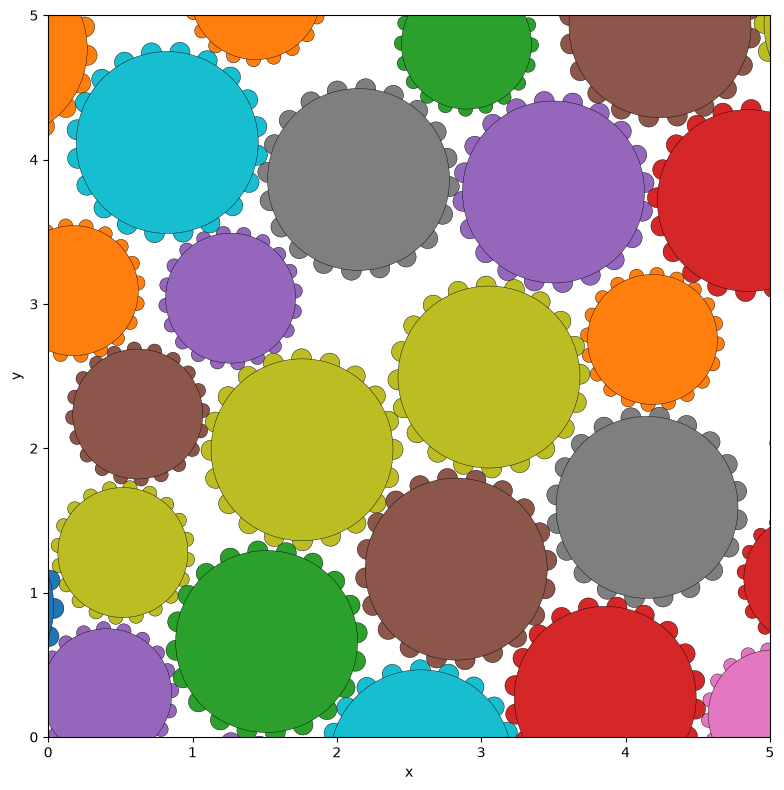

In [15]:
def _periodic_image_centers(px, py, r, x0, y0, w, h):
    if w <= 0 or h <= 0:
        yield float(px), float(py)
        return
    kx_lo = int(np.ceil((x0 - r - px) / w))
    kx_hi = int(np.floor((x0 + w + r - px) / w))
    ky_lo = int(np.ceil((y0 - r - py) / h))
    ky_hi = int(np.floor((y0 + h + r - py) / h))
    for kx in range(kx_lo, kx_hi + 1):
        for ky in range(ky_lo, ky_hi + 1):
            yield float(px + kx * w), float(py + ky * h)


fig, ax = plt.subplots(figsize=(8, 8))

cid = np.asarray(state.clump_id, dtype=int).reshape(-1)
facecolors = [plt.cm.tab10(int(cid[i]) % 10) for i in range(pos.shape[0])]

box = np.asarray(system.domain.box_size).reshape(-1)
anch = np.asarray(system.domain.anchor).reshape(-1)

w, h = float(box[0]), float(box[1])
x0, y0 = float(anch[0]), float(anch[1])
for i in range(pos.shape[0]):
	px, py = float(pos[i, 0]), float(pos[i, 1])
	ri = float(rad[i])
	for cx, cy in _periodic_image_centers(px, py, ri, x0, y0, w, h):
		ax.add_patch(
			Circle(
				(cx, cy),
				ri,
				facecolor=facecolors[i],
				edgecolor="k",
				linewidth=0.3,
			)
		)
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
# ax.set_xlim(x0, x0 + w)
# ax.set_ylim(y0, y0 + h)

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

In [16]:
results = []

for cid in np.unique(state.clump_id):
    mask = np.asarray(state.clump_id) == cid
    pos = np.asarray(state.pos)[mask]
    rad = np.asarray(state.rad)[mask]
    center = np.asarray(state.pos_c)[mask][0]

    # Remove the solid core.
    rho = np.linalg.norm(pos - center, axis=1)
    shell = rho > 0.5 * np.median(rho)
    pos, rad, rho = pos[shell], rad[shell], rho[shell]

    # Order adjacent asperities around the particle.
    angles = np.arctan2(pos[:, 1] - center[1], pos[:, 0] - center[0])
    order = np.argsort(angles)
    pos, rad = pos[order], rad[order]

    distance = np.linalg.norm(np.roll(pos, -1, axis=0) - pos, axis=1)
    ratio = np.mean(distance / (rad + np.roll(rad, -1)))

    particle_radius = np.mean(rho + rad)
    results.append((particle_radius, ratio))

results = np.asarray(results)
midpoint = (results[:, 0].min() + results[:, 0].max()) / 2

print("Small:", results[results[:, 0] < midpoint, 1].mean())
print("Large:", results[results[:, 0] > midpoint, 1].mean())

Small: 1.4142135623728278
Large: 1.4142135623728276
